SUPRIYA K 
24BAD118


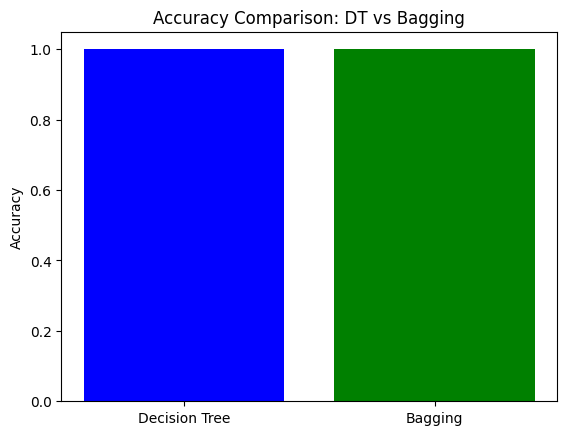

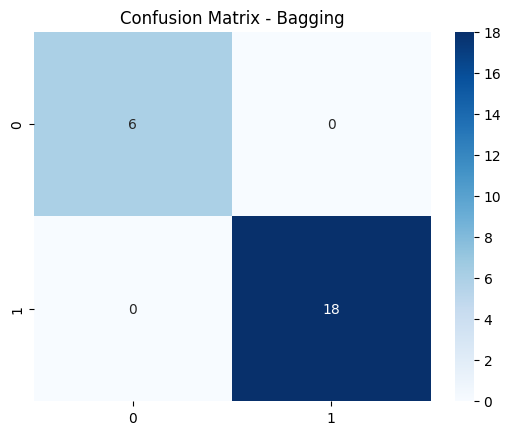

In [8]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
df = pd.read_csv('diabetes_bagging.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bagging.predict(X_test))
plt.bar(['Decision Tree', 'Bagging'], [dt_acc, bag_acc], color=['blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: DT vs Bagging')
plt.show()
sns.heatmap(confusion_matrix(y_test, bagging.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Bagging')
plt.show()

SUPRIYA K 
24BAD118


C:\Users\supri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\supri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


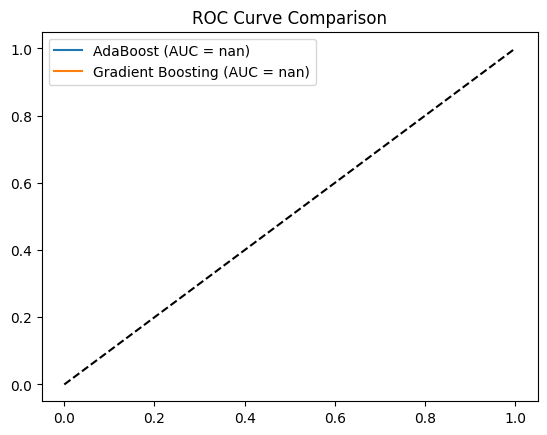

In [7]:
print("SUPRIYA K \n24BAD118")
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('churn_boosting.csv')
le = LabelEncoder()
df['ContractType'] = le.fit_transform(df['ContractType'])
df['InternetService'] = le.fit_transform(df['InternetService'])
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
gbc.fit(X_train, y_train)
for model, name in [(ada, 'AdaBoost'), (gbc, 'Gradient Boosting')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()

SUPRIYA K 
24BAD118


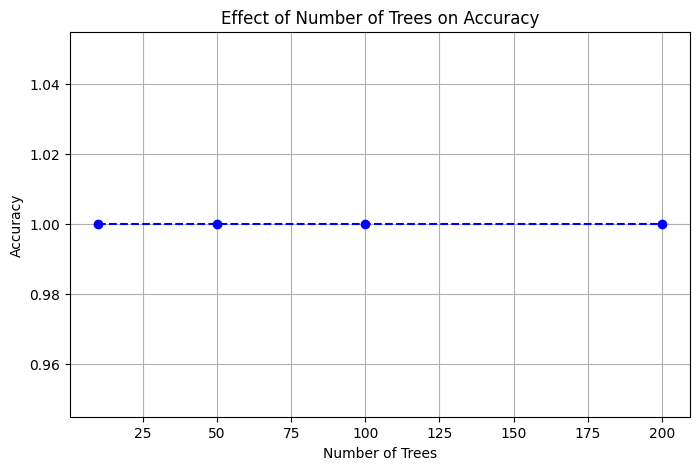

C:\Users\supri\AppData\Local\Temp\ipykernel_24596\1257402689.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


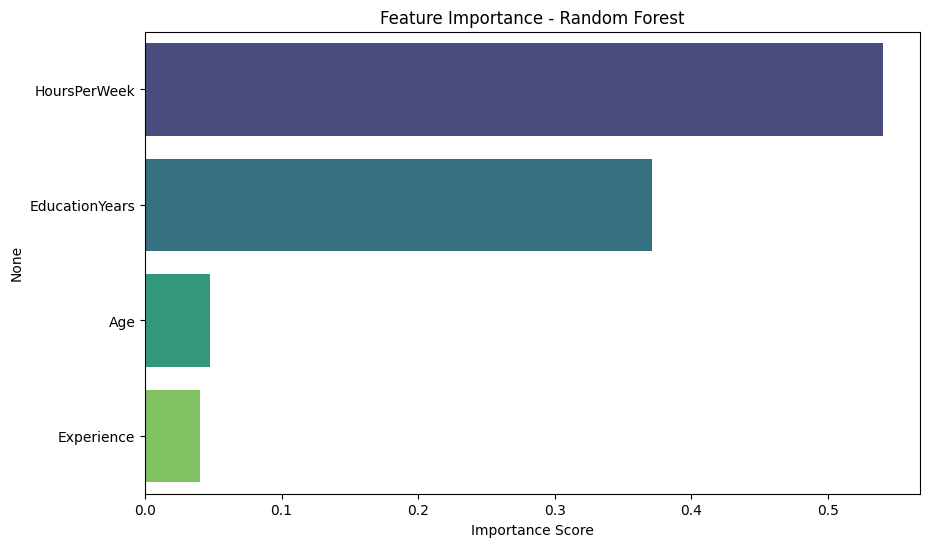

Final Model Accuracy (100 trees): 1.0000


In [13]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('income_random_forest.csv')
X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_list = []
trees = [10, 50, 100, 200]
for n in trees:
    temp_rf = RandomForestClassifier(n_estimators=n, random_state=42)
    temp_rf.fit(X_train, y_train)
    acc_list.append(accuracy_score(y_test, temp_rf.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(trees, acc_list, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Effect of Number of Trees on Accuracy')
plt.grid(True)
plt.show()

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print(f"Final Model Accuracy (100 trees): {accuracy_score(y_test, rf.predict(X_test)):.4f}")

SUPRIYA K 
24BAD118


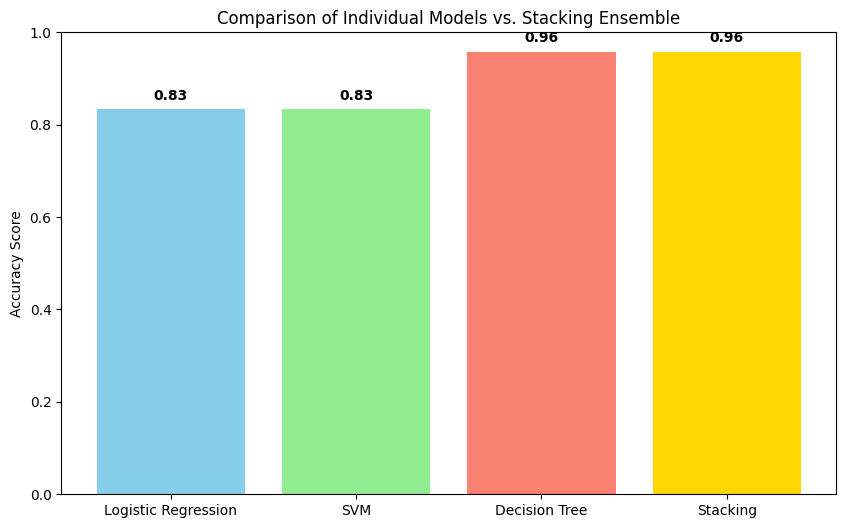

In [11]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv('heart_stacking.csv')
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stacking = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stacking.fit(X_train, y_train)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Stacking': stacking
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results[name] = accuracy_score(y_test, predictions)
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.ylabel('Accuracy Score')
plt.title('Comparison of Individual Models vs. Stacking Ensemble')
plt.ylim(0, 1.0) # Set limit from 0 to 100%
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

SUPRIYA K 
24BAD118
Class distribution before SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64

Class distribution after SMOTE:
Fraud
0    110
1    110
Name: count, dtype: int64


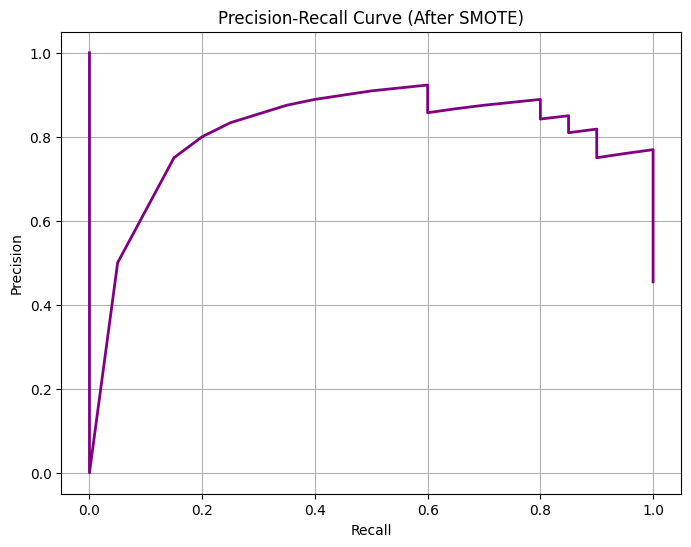

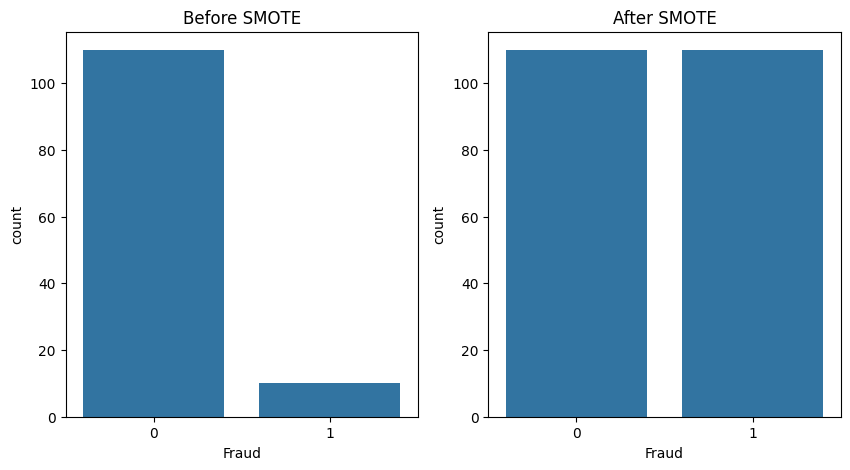


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.82      0.90      0.86        20

    accuracy                           0.86        44
   macro avg       0.86      0.87      0.86        44
weighted avg       0.87      0.86      0.86        44



In [2]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
df = pd.read_csv('fraud_smote.csv')
X = df.drop('Fraud', axis=1)
y = df['Fraud']
print("Class distribution before SMOTE:")
print(y.value_counts())
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (After SMOTE)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y).set_title('Before SMOTE')
plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled).set_title('After SMOTE')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))